In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive', force_remount = True)
clean_path = '/content/drive/MyDrive/Aerosol/files/Model'

Mounted at /content/drive


In [ ]:
thisstudy=pd.read_csv(clean_path+'/This_Study.csv')
choi=pd.read_csv(clean_path+'/Choi.csv')

In [ ]:
choirf_df= choi.copy()
thisrf_df= thisstudy.copy()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Filter valid predictions
mask = choirf_df['Predicted_Aerosol_Type'].notna() & (choirf_df['Predicted_Aerosol_Type'] != -1)

# Actual and predicted values
y_true = choirf_df.loc[mask, 'Aerosol_Type_PLDR']
y_pred = choirf_df.loc[mask, 'Predicted_Aerosol_Type']

# Get sorted class labels
classes = sorted(y_true.unique())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Producer's Accuracy per class
producer_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

# Convert to lists if needed
classes = list(classes)
producer_accuracy = list(producer_accuracy)

producer_accuracy

[np.float64(91.66666666666666),
 np.float64(65.44117647058823),
 np.float64(80.32619775739042),
 np.float64(66.13545816733067),
 np.float64(62.8099173553719),
 np.float64(65.4353562005277),
 np.float64(78.0)]

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Filter valid predictions
mask = thisrf_df['Predicted_Aerosol_Type'].notna() & (thisrf_df['Predicted_Aerosol_Type'] != -1)

# Actual and predicted values
y_true = thisrf_df.loc[mask, 'Aerosol_Type_PLDR']
y_pred = thisrf_df.loc[mask, 'Predicted_Aerosol_Type']

# Get sorted class labels
classes = sorted(y_true.unique())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Producer's Accuracy per class
producer_accuracy_this = cm.diagonal() / cm.sum(axis=1) * 100

# Convert to lists if needed
classes = list(classes)
producer_accuracy_this = list(producer_accuracy_this)

producer_accuracy_this

[np.float64(91.66666666666666),
 np.float64(70.29702970297029),
 np.float64(77.42146596858639),
 np.float64(56.33074935400517),
 np.float64(57.18475073313783),
 np.float64(65.43001686340641),
 np.float64(77.720207253886)]

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Filter valid predictions
mask = choirf_df['4_Predicted_Aerosol_Type'].notna() & (choirf_df['4_Predicted_Aerosol_Type'] != -1)

# Actual and predicted values
y_true = choirf_df.loc[mask, '4_Aerosol_Type']
y_pred = choirf_df.loc[mask, '4_Predicted_Aerosol_Type']

# Get sorted class labels
classes = sorted(y_true.unique())
# Confusion matrix
cm_4 = confusion_matrix(y_true, y_pred, labels=classes)

# Producer's Accuracy per class
producer_accuracy_4 = cm_4.diagonal() / cm_4.sum(axis=1) * 100

# Convert to lists if needed
classes = list(classes)
producer_accuracy_4 = list(producer_accuracy_4)

producer_accuracy_4

[np.float64(91.66666666666666),
 np.float64(66.17647058823529),
 np.float64(79.04191616766467),
 np.float64(87.54499640028797)]

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Filter valid predictions
mask = thisrf_df['4_Predicted_Aerosol_Type'].notna() & (thisrf_df['4_Predicted_Aerosol_Type'] != -1)

# Actual and predicted values
y_true = thisrf_df.loc[mask, '4_Aerosol_Type']
y_pred = thisrf_df.loc[mask, '4_Predicted_Aerosol_Type']

# Get sorted class labels
classes = sorted(y_true.unique())

# Confusion matrix
cm_4 = confusion_matrix(y_true, y_pred, labels=classes)

# Producer's Accuracy per class
producer_accuracy_this_4 = cm_4.diagonal() / cm_4.sum(axis=1) * 100

# Convert to lists if needed
classes = list(classes)
producer_accuracy_this_4 = list(producer_accuracy_this_4)

producer_accuracy_this_4

[np.float64(91.66666666666666),
 np.float64(73.76237623762376),
 np.float64(79.8800799467022),
 np.float64(83.61445783132531)]

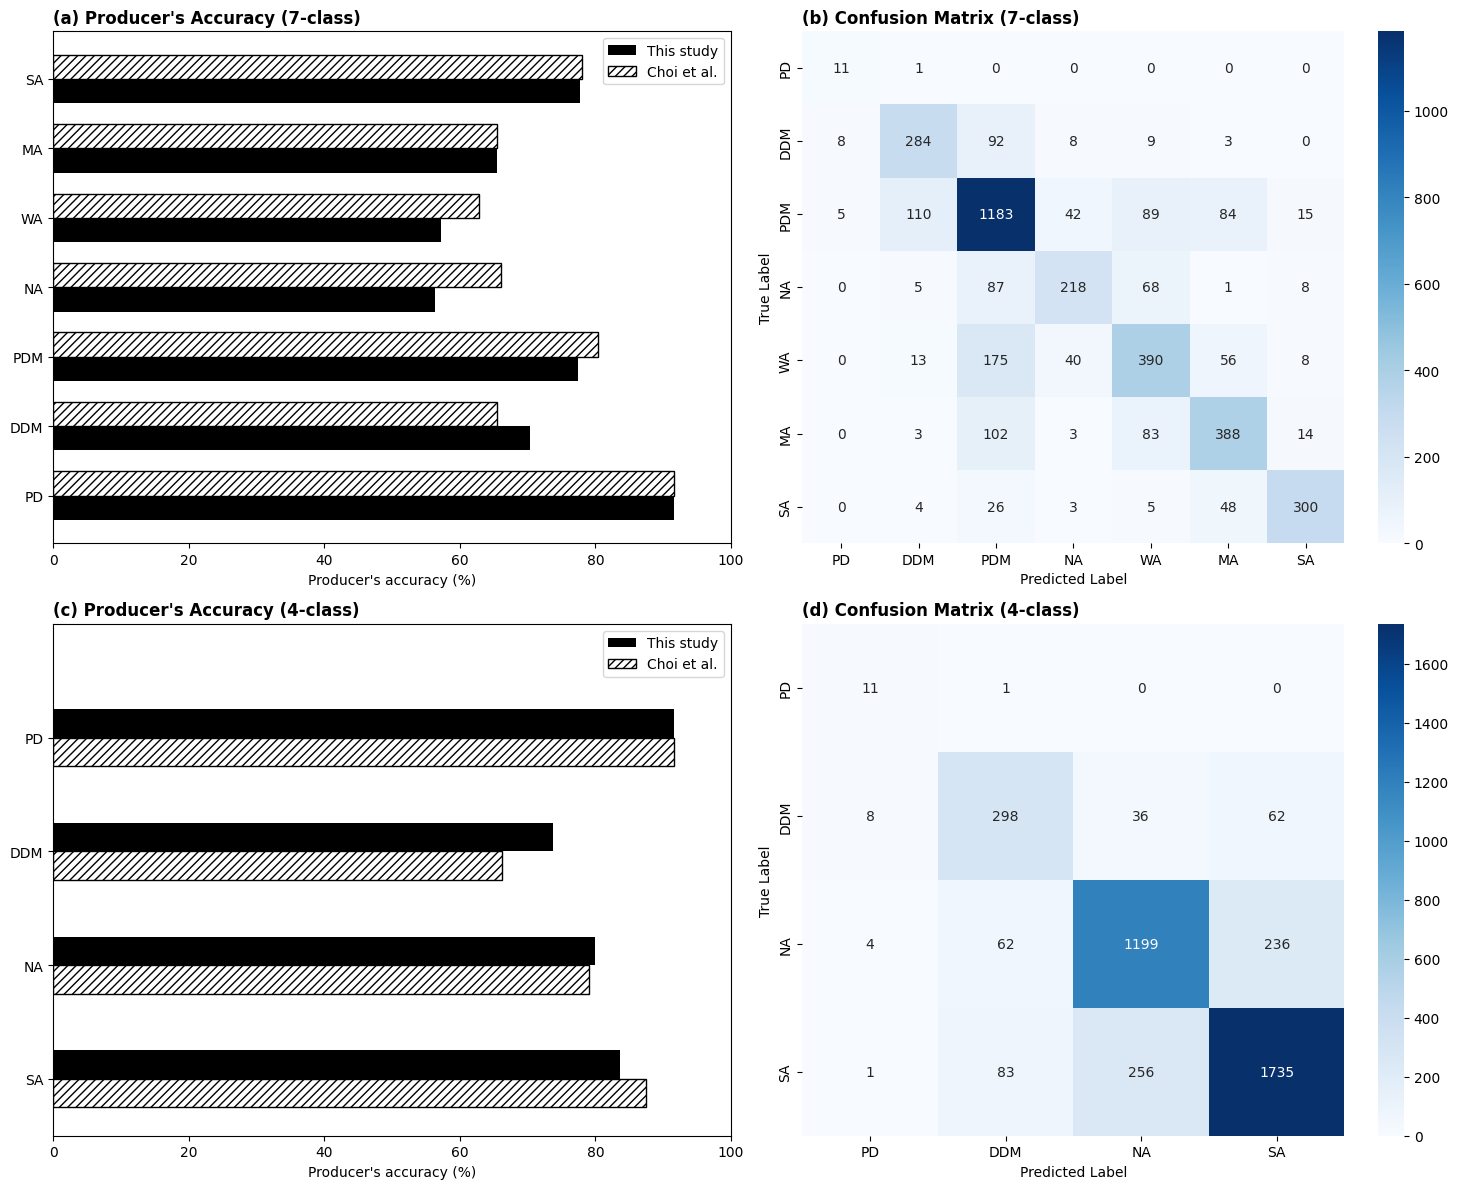

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define aerosol types
aerosol_types_7 = ['PD', 'DDM', 'PDM', 'NA', 'WA', 'MA', 'SA']
aerosol_types_4 = ['PD', 'DDM', 'NA', 'SA']

# Define bar width and positions
bar_width = 0.35
bar_width_4 = 0.25
y_pos_7 = np.arange(len(aerosol_types_7))
y_pos_4 = np.arange(len(aerosol_types_4))

# Create a 2-row, 2-column grid for subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- First Row (7-class) ---
# (a) Horizontal bar chart
ax1 = axes[0, 0]
bars1 = ax1.barh(y_pos_7 - bar_width/2, producer_accuracy_this, bar_width,
                 label='This study', color='black')
bars2 = ax1.barh(y_pos_7 + bar_width/2, producer_accuracy, bar_width,
                 label='Choi et al.', hatch='////', edgecolor='black', fill=False)

ax1.set_xlabel("Producer's accuracy (%)")
ax1.set_yticks(y_pos_7)
ax1.set_yticklabels(aerosol_types_7)
ax1.set_xlim(0, 100)
ax1.set_title("(a) Producer's Accuracy (7-class)", loc='left', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10, frameon=True)

# (b) Confusion Matrix
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=aerosol_types_7, yticklabels=aerosol_types_7, ax=ax2)
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')
ax2.set_title('(b) Confusion Matrix (7-class)', loc='left', fontsize=12, fontweight='bold')

# --- Second Row (4-class) ---
# (c) Horizontal bar chart
ax3 = axes[1, 0]
bars3 = ax3.barh(y_pos_4 - bar_width_4/2, producer_accuracy_this_4, bar_width_4,
                 label='This study', color='black')
bars4 = ax3.barh(y_pos_4 + bar_width_4/2, producer_accuracy_4, bar_width_4,
                 label='Choi et al.', hatch='////', edgecolor='black', fill=False)

ax3.set_xlabel("Producer's accuracy (%)")
ax3.set_yticks(y_pos_4)
ax3.set_yticklabels(aerosol_types_4)
ax3.set_xlim(0, 100)
ax3.set_ylim(len(aerosol_types_4) - 0.5, -1)  # Add space at top
ax3.set_title("(c) Producer's Accuracy (4-class)", loc='left', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10, frameon=True)

# (d) Confusion Matrix
ax4 = axes[1, 1]
sns.heatmap(cm_4, annot=True, fmt='d', cmap='Blues',
            xticklabels=aerosol_types_4, yticklabels=aerosol_types_4, ax=ax4)
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('True Label')
ax4.set_title('(d) Confusion Matrix (4-class)', loc='left', fontsize=12, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.show()


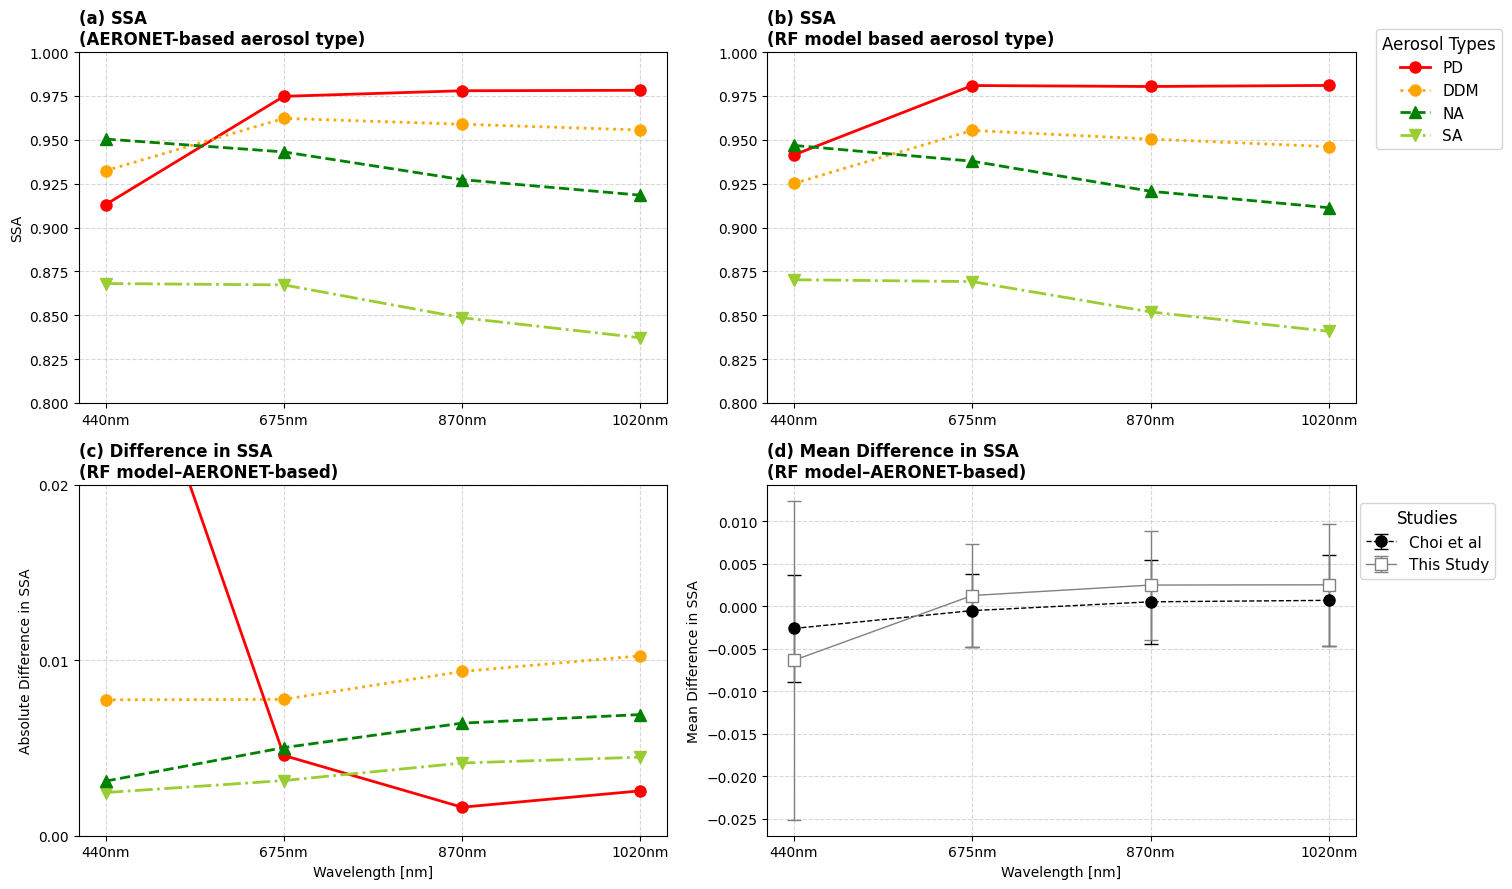

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Configuration ---
plot_styles_map = {
    0: ('PD', 'red', 'o', '-'),
    1: ('DDM', 'orange', 'o', ':'),
    6: ('SA', 'yellowgreen', 'v', '-.'),
    3: ('NA', 'green', '^', '--'),
    -1: ('Unknown', 'gray', 's', '--')
}

wavelengths = ['440nm', '675nm', '870nm', '1020nm']
ssa_columns = [f'Single_Scattering_Albedo[{wl}]' for wl in wavelengths]
valid_labels = [0, 1, 6, 3]

# --- Helper Functions ---
def plot_grouped_ssa(ax, df, label_col, title, ylabel="", xlabel="", ylim=(0.8, 1.0), title_id=""):
    grouped = df[df[label_col].isin(valid_labels)].groupby(label_col)
    for label, group in grouped:
        mean_ssa = group[ssa_columns].mean()
        style = plot_styles_map[label]
        ax.plot(
            wavelengths, mean_ssa,
            label=style[0],
            color=style[1], marker=style[2], linestyle=style[3],
            linewidth=2, markersize=8
        )
    ax.set_title(f"{title_id} {title}", loc='left', fontsize=12, weight='bold')
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.grid(True, linestyle='--', alpha=0.5)

def compute_mean_std_diff(df):
    true = df.groupby('4_Aerosol_Type')[ssa_columns].mean()
    pred = df.groupby('4_Predicted_Aerosol_Type')[ssa_columns].mean()
    return (true - pred).mean(), (true - pred).std()

# --- Layout Setup: 2 rows, 2 columns ---
fig, axes = plt.subplots(2, 2, figsize=(15, 9))  # Bigger plots
((ax1, ax2), (ax3, ax4)) = axes

# --- Subplot (a): AERONET-based ---
plot_grouped_ssa(
    ax=ax1, df=thisstudy, label_col='4_Aerosol_Type',
    title="SSA\n(AERONET-based aerosol type)",
    ylabel="SSA", title_id="(a)"
)

# --- Subplot (b): RF Predicted ---
plot_grouped_ssa(
    ax=ax2, df=thisstudy, label_col='4_Predicted_Aerosol_Type',
    title="SSA\n(RF model based aerosol type)",
    title_id="(b)"
)

# --- Subplot (c): Absolute Difference ---
filtered_diff = thisstudy[
    thisstudy['4_Aerosol_Type'].isin(valid_labels) &
    thisstudy['4_Predicted_Aerosol_Type'].isin(valid_labels)
]
true_means = filtered_diff.groupby('4_Aerosol_Type')[ssa_columns].mean()
pred_means = filtered_diff.groupby('4_Predicted_Aerosol_Type')[ssa_columns].mean()

for label in valid_labels:
    if label in true_means.index and label in pred_means.index:
        abs_diff = (true_means.loc[label] - pred_means.loc[label]).abs()
        style = plot_styles_map[label]
        ax3.plot(
            wavelengths, abs_diff,
            label=style[0],
            color=style[1], marker=style[2], linestyle=style[3],
            linewidth=2, markersize=8
        )

ax3.set_title("(c) Difference in SSA\n(RF model–AERONET-based)", loc='left', fontsize=12, weight='bold')
ax3.set_ylabel("Absolute Difference in SSA")
ax3.set_xlabel("Wavelength [nm]")
ax3.set_ylim(0, 0.02)
ax3.set_yticks([0.0, 0.01, 0.02])
ax3.grid(True, linestyle='--', alpha=0.5)

# --- Subplot (d): Mean Difference w/ Error Bars ---
mean_diff_this, std_diff_this = compute_mean_std_diff(filtered_diff)

filtered_choi = choi[
    choi['4_Aerosol_Type'].isin(valid_labels) &
    choi['4_Predicted_Aerosol_Type'].isin(valid_labels)
]
mean_diff_choi, std_diff_choi = compute_mean_std_diff(filtered_choi)

# Plot both
line1 = ax4.errorbar(
    wavelengths, mean_diff_choi,
    yerr=std_diff_choi,
    label="Choi et al",
    marker='o', linestyle='--', color='black',
    linewidth=1, markersize=8, capsize=5, elinewidth=1,
    markerfacecolor='black'
)

line2 = ax4.errorbar(
    wavelengths, mean_diff_this,
    yerr=std_diff_this,
    label="This Study",
    marker='s', linestyle='-', color='gray',  # solid line
    linewidth=1, markersize=8, capsize=5, elinewidth=1,
    markerfacecolor='white', markeredgecolor='gray'  # hollow
)

ax4.set_ylabel("Mean Difference in SSA")
ax4.set_xlabel("Wavelength [nm]")
ax4.set_title("(d) Mean Difference in SSA\n(RF model–AERONET-based)", loc='left', fontsize=12, weight='bold')
ax4.grid(True, linestyle='--', alpha=0.5)

# --- Shared Legend for (a)–(c) ---
handles_common, labels_common = ax1.get_legend_handles_labels()
fig.legend(
    handles_common, labels_common,
    loc='upper right', bbox_to_anchor=(1.01, 0.97),
    title="Aerosol Types", fontsize=11, title_fontsize=12
)

# --- Subplot-specific legend for (d) ---
handles_d, labels_d = ax4.get_legend_handles_labels()
ax4.legend(
    handles=handles_d, labels=labels_d,
    loc='upper right', bbox_to_anchor=(1.25, 0.97),
    title="Studies", fontsize=11, title_fontsize=12
)

# --- Layout Adjustments ---
plt.tight_layout(rect=[0, 0, 1, 1])  # Leave room on the right
plt.show()


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 40.8 MB/s eta 0:00:00


In [ ]:
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [ ]:
this_map= pd.read_csv('drive/MyDrive/Aerosol/files/Map Plot/This_Map.csv')
choi_map= pd.read_csv('drive/MyDrive/Aerosol/files/Map Plot/Choi_Map.csv')

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


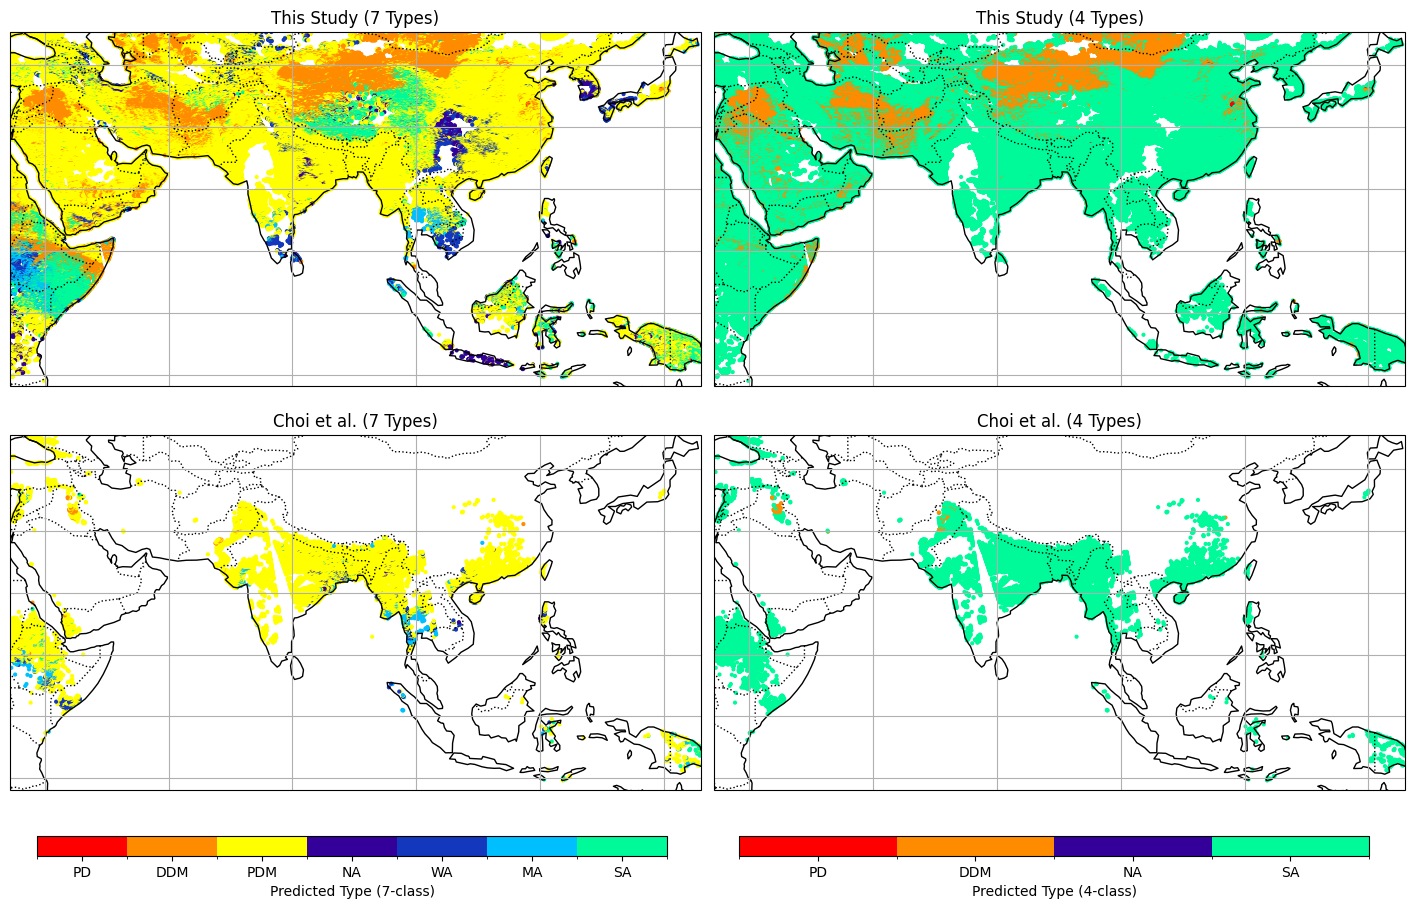

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec


min_lat, min_lon, max_lat, max_lon = -11.8, 34.4, 45.4, 145.9

def filter_bbox(df):
    return df[
        (df['Latitude'] >= min_lat) & (df['Latitude'] <= max_lat) &
        (df['Longitude'] >= min_lon) & (df['Longitude'] <= max_lon)
    ]

this_bbox = filter_bbox(this_map)
choi_bbox = filter_bbox(choi_map)

# Colormaps
cmap7 = mcolors.ListedColormap(['#ff0000', '#ff8c00', '#ffff00', '#330099', '#1338be', '#00bfff', '#00fa9a'])
labels7 = ['PD', 'DDM', 'PDM', 'NA', 'WA', 'MA', 'SA']
bounds7 = list(range(8))
norm7 = mcolors.BoundaryNorm(bounds7, cmap7.N)

cmap4 = mcolors.ListedColormap(['#ff0000', '#ff8c00', '#330099', '#00fa9a'])
labels4 = ['PD', 'DDM', 'NA', 'SA']
bounds4 = list(range(5))
norm4 = mcolors.BoundaryNorm(bounds4, cmap4.N)

# Plot
fig = plt.figure(figsize=(18, 10))
proj = ccrs.PlateCarree()
gs = fig.add_gridspec(2, 2, hspace=0.1, wspace=0.02)
axs = gs.subplots(subplot_kw={'projection': proj})

datasets = [(this_bbox, cmap7, norm7, labels7, 'Predicted_Type', 'This Study (7 Types)'),
            (this_bbox, cmap4, norm4, labels4, 'Predicted_Type_4', 'This Study (4 Types)'),
            (choi_bbox, cmap7, norm7, labels7, 'Predicted_Type', 'Choi et al. (7 Types)'),
            (choi_bbox, cmap4, norm4, labels4, 'Predicted_Type_4', 'Choi et al. (4 Types)')]

scs = []  # Collect scatter objects for colorbars

for ax, (data, cmap, norm, labels, col, title) in zip(axs.flat, datasets):
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=proj)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.gridlines(draw_labels=False)
    sc = ax.scatter(data['Longitude'], data['Latitude'], c=data[col], cmap=cmap,
                    norm=norm, s=4, transform=proj)
    ax.set_title(title, fontsize=12)
    scs.append((sc, labels))

# Colorbars
tick_locs7 = [i + 0.5 for i in range(7)]
tick_locs4 = [i + 0.5 for i in range(4)]

# Left (7 types)
cbar_ax_left = fig.add_axes([0.14, 0.05, 0.35, 0.02])
cbar_left = fig.colorbar(scs[0][0], cax=cbar_ax_left, ticks=tick_locs7, orientation='horizontal')
cbar_left.ax.set_xticklabels(scs[0][1])
cbar_left.set_label("Predicted Type (7-class)")

# Right (4 types)
cbar_ax_right = fig.add_axes([0.53, 0.05, 0.35, 0.02])
cbar_right = fig.colorbar(scs[1][0], cax=cbar_ax_right, ticks=tick_locs4, orientation='horizontal')
cbar_right.ax.set_xticklabels(scs[1][1])
cbar_right.set_label("Predicted Type (4-class)")

plt.show()